<a href="https://colab.research.google.com/github/boyranger/ev-charger-behavior/blob/main/spklu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Read the data from the Excel file into a pandas DataFrame
df = pd.read_excel('/content/drive/MyDrive/spklu.xlsx')

# You can now use the DataFrame for further processing

In [3]:
df

,No,Periode,Tanggal,Provinsi,Pemda/Pemkot,Nama SPKLU,EV Charger,Daya Charger,kwh,durasi
0,110,202301,2023-01-05 12:26:59.099,JAWA BARAT,KAB. BANDUNG,SPKLU PLN UP3 MAJALAYA,Delta AC Max,22 kW,13.07,01:57:12
1,206,202301,2023-01-08 10:59:42.639,JAWA BARAT,KAB. BANDUNG,SPKLU GEDUNG BUDAYA SABILULUNGAN,Delta AC Max,22 kW,2.76,00:24:47
2,267,202301,2023-01-10 10:27:45.792,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22 kW,2.54,00:22:27
3,299,202301,2023-01-12 15:31:43.829,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22 kW,1.59,00:43:59
4,370,202301,2023-01-14 17:49:22.822,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO CIWIDEY,Delta AC Max,22 kW,0.00,00:05:54
...,...,...,...,...,...,...,...,...,...,...
160533,160047,202502,2025-02-28 08:34:39.222,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,Delta DC Wallbox,25 kW,24.68,01:03:14
160534,160070,202502,2025-02-28 09:19:41.492,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,1. Delta AC Max,22 kW,2.94,00:25:58
160535,160087,202502,2025-02-28 09:49:22.600,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,Delta DC Wallbox,25 kW,12.92,01:09:29
160536,160108,202502,2025-02-28 10:18:45.035,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,2. Delta AC Max,22 kW,1.24,00:40:30


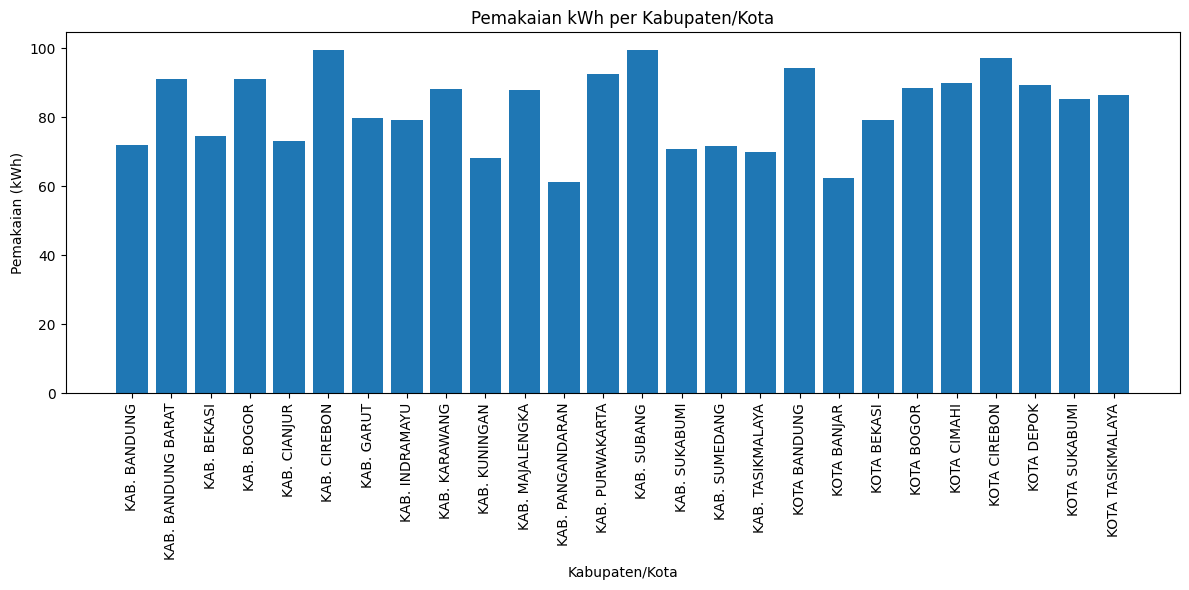

In [5]:
# prompt: buat grafik pemakaian kwh per kab/kota

import matplotlib.pyplot as plt

# Assuming 'Kabupaten/Kota' and 'Pemakaian (kWh)' are column names in your DataFrame
kabupaten_kota = df['Pemda/Pemkot']
pemakaian_kwh = df['kwh']

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.bar(kabupaten_kota, pemakaian_kwh)
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Pemakaian (kWh)')
plt.title('Pemakaian kWh per Kabupaten/Kota')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability if needed
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


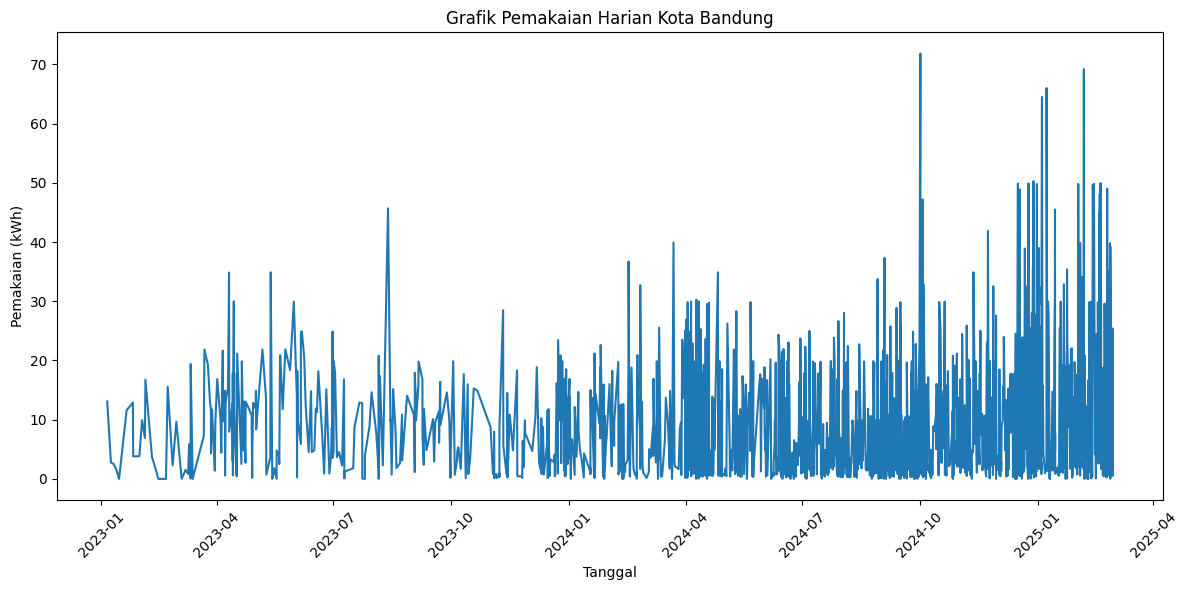

In [5]:
# prompt: grafik  profile pmakaian harian kota bandung

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
# and you have columns named 'Tanggal' and 'Pemakaian (kWh)'

# If 'Tanggal' is not a datetime object, convert it
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Filter data for Bandung
bandung_data = df[df['Pemda/Pemkot'] == 'KAB. BANDUNG']

# Group data by date and sum the daily consumption
daily_consumption = bandung_data.groupby('Tanggal')['kwh'].sum()


plt.figure(figsize=(12, 6))
plt.plot(daily_consumption.index, daily_consumption.values)
plt.xlabel('Tanggal')
plt.ylabel('Pemakaian (kWh)')
plt.title('Grafik Pemakaian Harian Kota Bandung')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


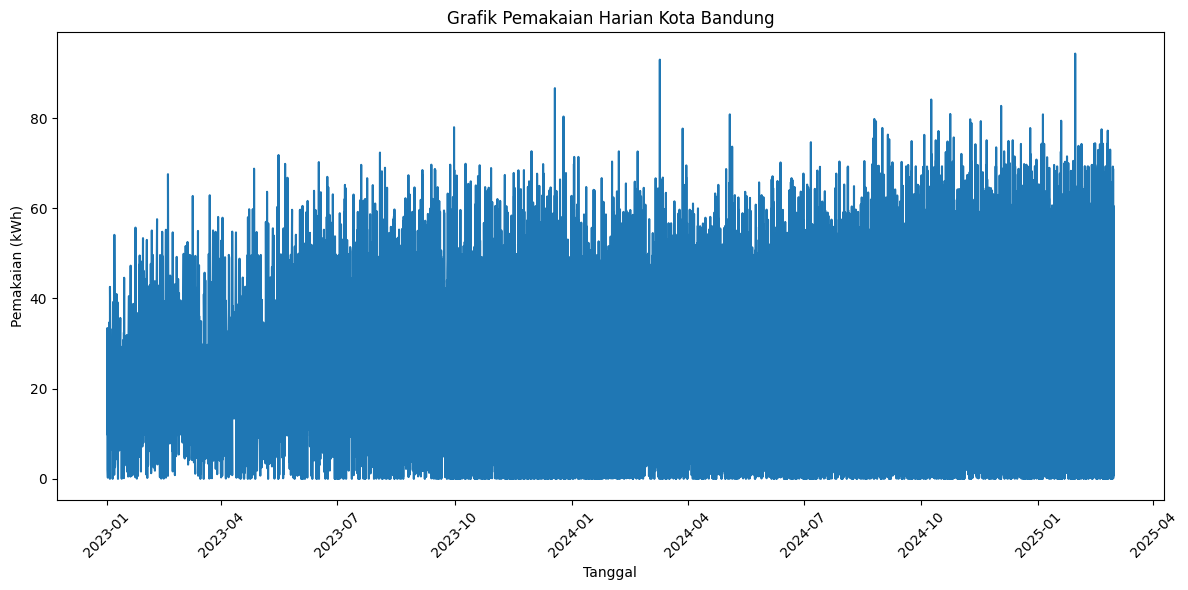

In [6]:
# prompt: grafik  profile pmakaian harian kota bandung

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
# and you have columns named 'Tanggal' and 'Pemakaian (kWh)'

# If 'Tanggal' is not a datetime object, convert it
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Filter data for Bandung
bandung_data = df[df['Pemda/Pemkot'] == 'KOTA BANDUNG']

# Group data by date and sum the daily consumption
daily_consumption = bandung_data.groupby('Tanggal')['kwh'].sum()


plt.figure(figsize=(12, 6))
plt.plot(daily_consumption.index, daily_consumption.values)
plt.xlabel('Tanggal')
plt.ylabel('Pemakaian (kWh)')
plt.title('Grafik Pemakaian Harian Kota Bandung')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


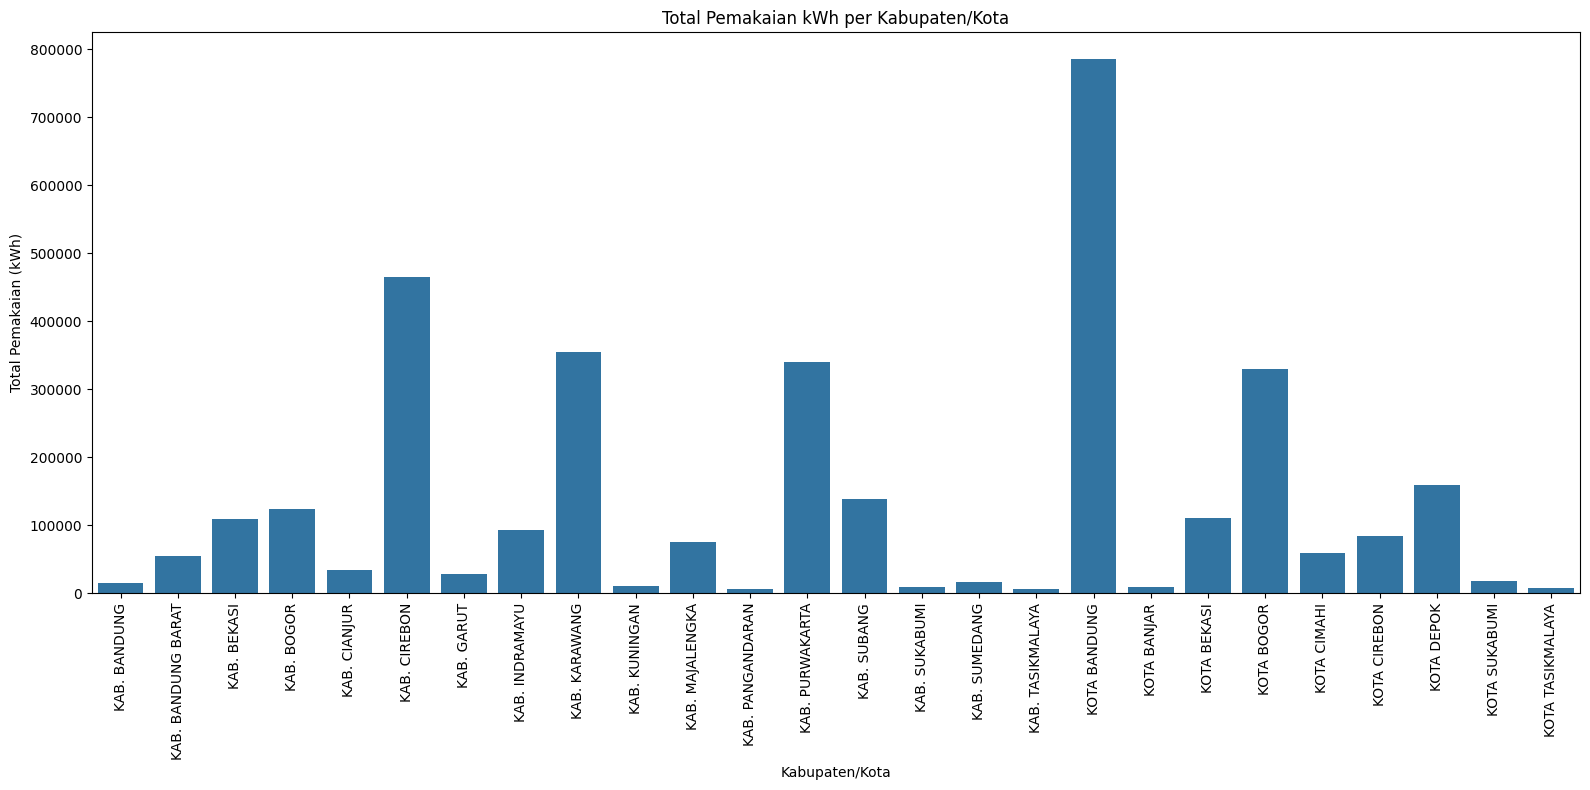

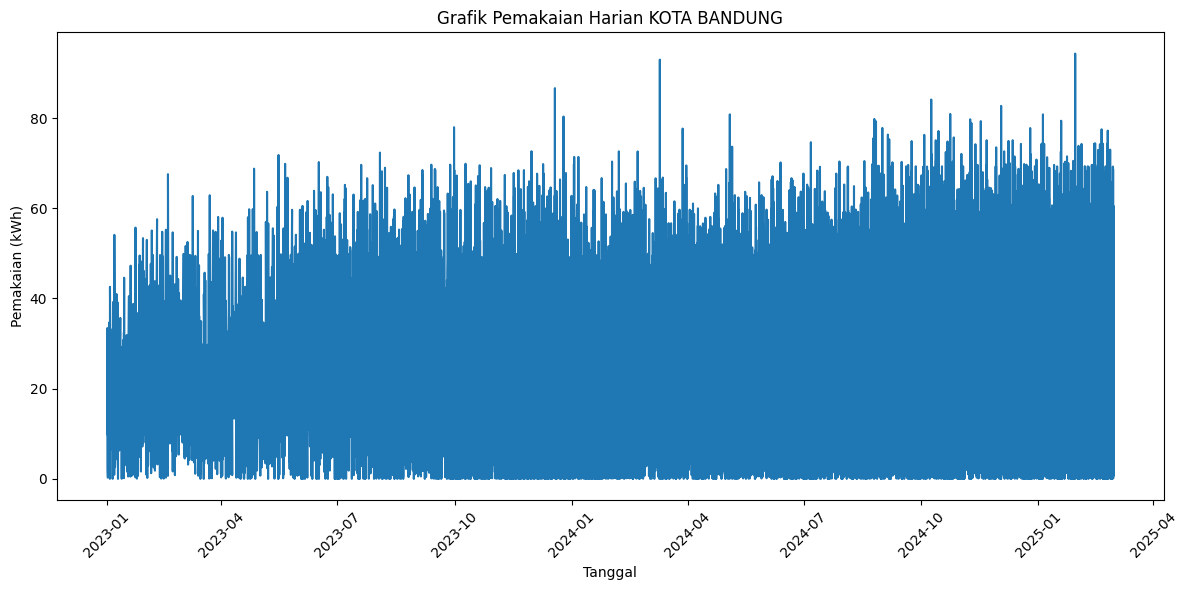

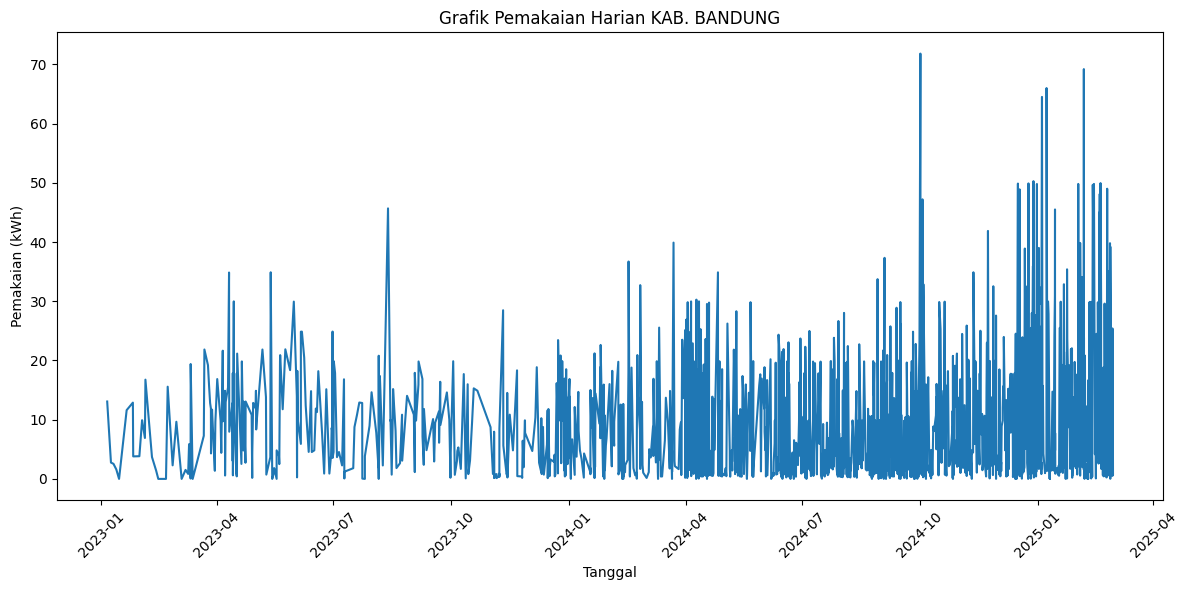

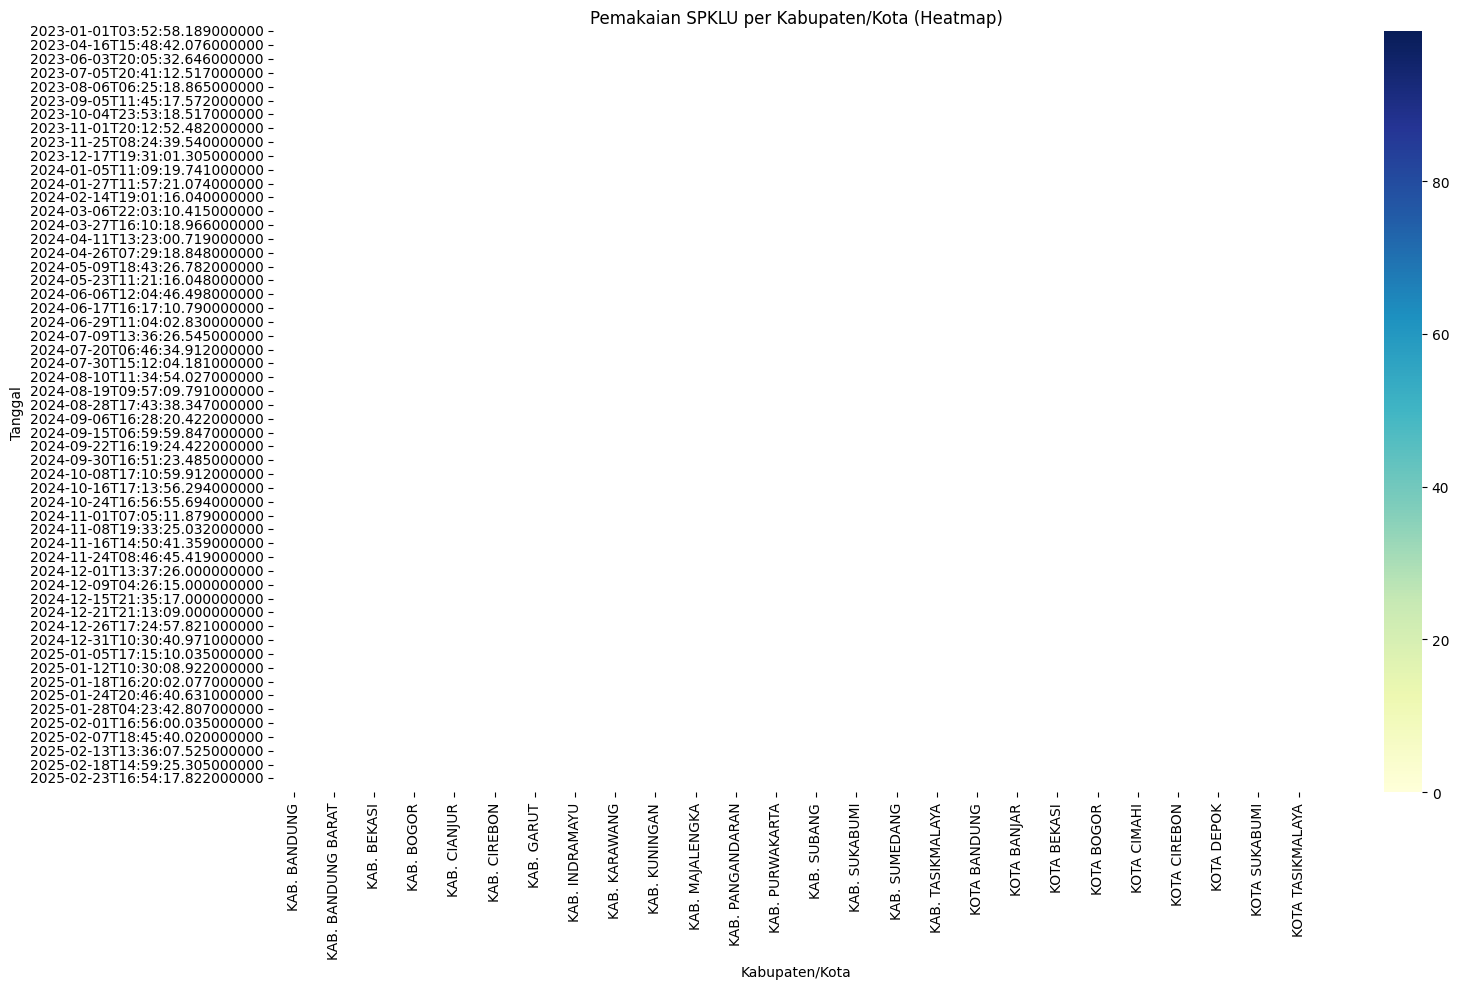

In [7]:
# prompt: Analisis Spasial dan Temporal Penggunaan SPKLU di Jawa Barat

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data from the Excel file into a pandas DataFrame
df = pd.read_excel('/content/drive/MyDrive/spklu.xlsx')

# Convert 'Tanggal' column to datetime objects
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# --- Spatial Analysis: Total Consumption per Region ---
spatial_df = df.groupby('Pemda/Pemkot')['kwh'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(x='Pemda/Pemkot', y='kwh', data=spatial_df)
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Total Pemakaian (kWh)')
plt.title('Total Pemakaian kWh per Kabupaten/Kota')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- Temporal Analysis: Daily Consumption per Region ---
def plot_daily_consumption(region):
    region_data = df[df['Pemda/Pemkot'] == region]
    daily_consumption = region_data.groupby('Tanggal')['kwh'].sum()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_consumption.index, daily_consumption.values)
    plt.xlabel('Tanggal')
    plt.ylabel('Pemakaian (kWh)')
    plt.title(f'Grafik Pemakaian Harian {region}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Example usage: Plotting for Kota Bandung and Kab. Bandung
plot_daily_consumption('KOTA BANDUNG')
plot_daily_consumption('KAB. BANDUNG')


# --- Combined Spatial and Temporal Analysis (Heatmap) ---
# Create a pivot table for visualization
heatmap_data = df.pivot_table(index='Tanggal', columns='Pemda/Pemkot', values='kwh', aggfunc='sum')

plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, fmt=".0f", linewidths=.5)  # Use a colormap
plt.title("Pemakaian SPKLU per Kabupaten/Kota (Heatmap)")
plt.xlabel("Kabupaten/Kota")
plt.ylabel("Tanggal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
